## **1. Definition**
- This dataset contains information about the passengers of the RMS Titanic, which famously sank in 1912. Each row in the dataset represents a single passenger, and the columns contain various pieces of information about them, such as:
  - **PassengerId:** A unique identifier for each passenger.
  - **Survived:** Whether the passenger survived the sinking (this will be the main target variable to focusing on).
  - **Pclass:** The passenger's ticket class (1st, 2nd and 3rd class).
  - **Name:** The passenger's name.
  - **Sex:** The passenger's gender.
  - **Age:** The passenger's age.
  - **SibSp:** Number of siblings/spouses aboard.
  - **Parch:** Number of parents/children aboard.
  - **Ticket:** Ticket number.
  - **Fare:** The fare paid for the ticket.
  - **Cabin:** The cabin number.
  - **Embarked:** The port where the passenger embarked.
- The utmost reason to analyze this dataset, especially in the context of data science and machine learning, is typically to build a model that can predict whether a passenger survived the sinking based on the information available about them.

## **2. Import libraries**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **3. Load the dataset**

In [53]:
train_df = pd.read_csv('train.csv' , index_col="PassengerId")
test_df = pd.read_csv('test.csv' , index_col="PassengerId")

In [54]:
train_df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [55]:
test_df.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked'],
      dtype='object')

In [56]:
train_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### **3.1. Features Classification: Categorical and Numerical**
- This will help to decide which plot to use for visualization.
#### **Which are the categorical features?**
- Data that represents groups, labels, or categories.
- Include: `Survived`, `Sex`, `Embarked`, `Pclass`.
#### **Which are the numerical features?**
- Data that represents measurable quantities.
- Include: `Age`, `Fare`, `SibSp`, `Parch`.

<Axes: >

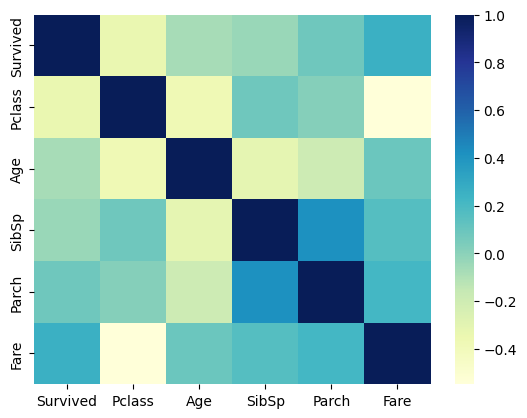

In [57]:
train_df = train_df.select_dtypes(include=np.number)
sns.heatmap(train_df.corr(), cmap='YlGnBu')

In [58]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 48.7 KB


In [59]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


In [60]:
features = ["Pclass", "SibSp", "Parch"]
def convert_cat(df, features):
  for feature in features:
    df[feature] = df[feature].astype('category')
  return df

train_df = convert_cat(train_df, features)
test_df = convert_cat(test_df, features)

In [61]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    category
 2   Age       714 non-null    float64 
 3   SibSp     891 non-null    category
 4   Parch     891 non-null    category
 5   Fare      891 non-null    float64 
dtypes: category(3), float64(2), int64(1)
memory usage: 31.3 KB


### **3.1.1. Distribution of Categorical features**

In [62]:
train_df.describe(include='category')

,Pclass,SibSp,Parch
count,891,891,891
unique,3,7,7
top,3,0,0
freq,491,608,678


### **3.1.2. Distribution of Numerical features**

In [63]:
train_df.describe()

,Survived,Age,Fare
count,891.000000,714.000000,891.000000
mean,0.383838,29.699118,32.204208
std,0.486592,14.526497,49.693429
min,0.000000,0.420000,0.000000
25%,0.000000,20.125000,7.910400
50%,0.000000,28.000000,14.454200
75%,1.000000,38.000000,31.000000
max,1.000000,80.000000,512.329200


## **4. Exploratory Data Analysis (EDA)**
### **4.1. Collerating categorical features**
- Catergorical: `Survived`, `Pclass`, `Sex`, `SibSp`,
       `Parch`, `Embarked`
### **Target variable: `Survived`**

In [64]:
train_df['Survived'].value_counts().to_frame()

,count
Survived,
0,549
1,342


In [65]:
train_df['Survived'].value_counts(normalize=True).to_frame()

,proportion
Survived,
0,0.616162
1,0.383838


Conclude that only 38% of the passengers survived. The data suffered from data imbalanced but not too severe to tackle the imbalance with data sampling.

#### **Sex**

In [66]:
train_df['Sex'].value_counts(normalize=True).to_frame()

KeyError: 'Sex'

In [ ]:
sns.countplot(x='Survived', hue='Sex', data=train_df)

ValueError: Could not interpret value `Sex` for `hue`. An entry with this name does not appear in `data`.

### **Remaining features**

ValueError: Could not interpret value `Sex` for `x`. An entry with this name does not appear in `data`.

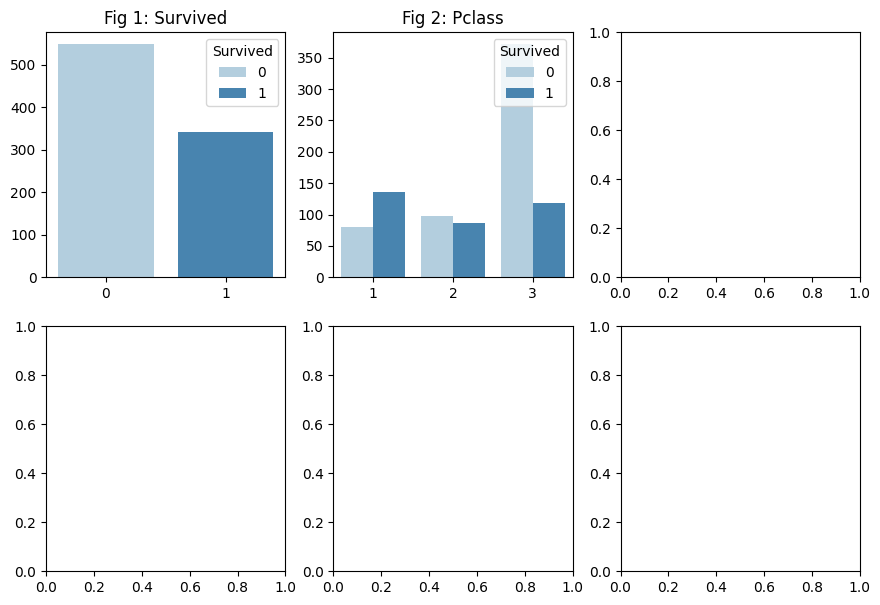

In [ ]:
cols = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

n_rows = 2
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3.5))

for r in range(n_rows):
  for c in range(0, n_cols):
    i = r*n_cols + c
    if i < len(cols):
      ax = axes[r][c]
      sns.countplot(x=cols[i], hue='Survived', data=train_df, ax=ax, palette='Blues')
      ax.set_title(f'Fig {i+1}: {cols[i]}')
      ax.legend(title='Survived', loc='upper right')
      ax.set_xlabel('')
      ax.set_ylabel('')

plt.tight_layout()

#### **Observation:**
- **Survival rate:**
  - Fig 2: Survival rate of the 1st class is the highest.
  - Fig 3: Female had significant higher survival rate than male.  
  - Fig 4 and 5: Passengers who were with 1 or 2 family members had higher chance than going alone.
  - Fig 6: Embarked on Southampton had better chance of surviving but also had the highest rate of not survived.

### **4.2. EDA for Numerical features**
- Numerical features: `Age`, `Fare`.

#### **Age**

In [ ]:
train_df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


<Axes: xlabel='Age', ylabel='Count'>

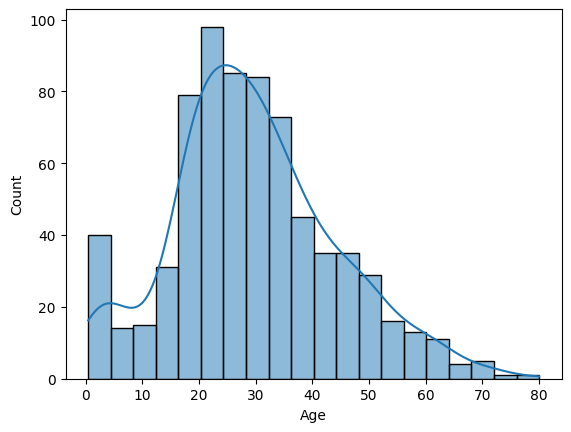

In [ ]:
sns.histplot(x='Age', data=train_df, kde=True)

<Axes: xlabel='Age', ylabel='Count'>

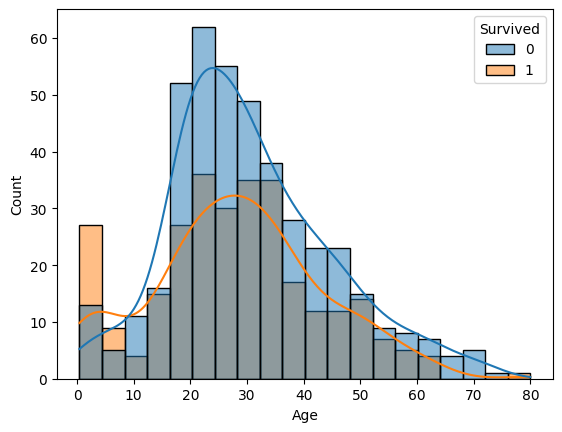

In [ ]:
sns.histplot(data=train_df, kde=True, x='Age', hue='Survived')

- The majority of passengers were around 18 to 35 years old.
- Children had higher chance of surviving due to the "women and children first" protocol.

#### **Fare**

In [ ]:
train_df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


<Axes: xlabel='Fare', ylabel='Count'>

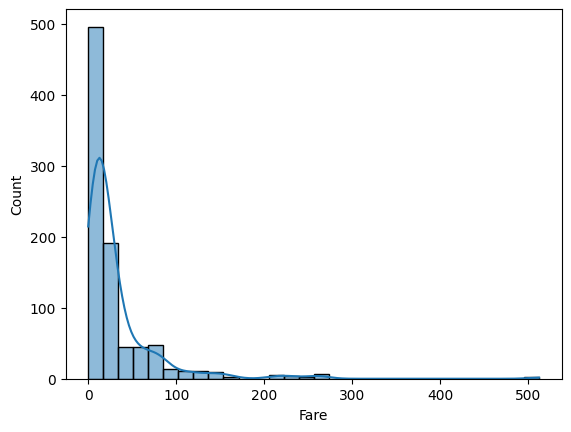

In [ ]:
sns.histplot(x='Fare', data=train_df, bins = 30, kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

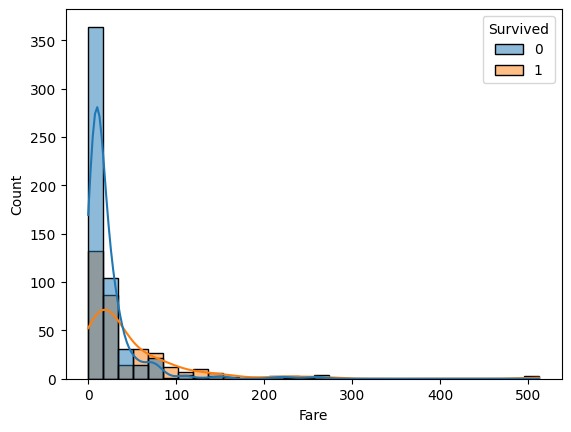

In [ ]:
sns.histplot(data=train_df, kde=True, x='Fare', bins = 30, hue='Survived')

In [ ]:
pd.qcut(train_df['Fare'], 4)

,Fare
PassengerId,
1,"(-0.001, 7.91]"
2,"(31.0, 512.329]"
3,"(7.91, 14.454]"
4,"(31.0, 512.329]"
5,"(7.91, 14.454]"
...,...
887,"(7.91, 14.454]"
888,"(14.454, 31.0]"
889,"(14.454, 31.0]"


In [ ]:
train_df['Fare_Category'] = pd.qcut(train_df['Fare'], 4)
display(train_df[['Fare', 'Fare_Category']].head())

,Fare,Fare_Category
PassengerId,,
1,7.2500,"(-0.001, 7.91]"
2,71.2833,"(31.0, 512.329]"
3,7.9250,"(7.91, 14.454]"
4,53.1000,"(31.0, 512.329]"
5,8.0500,"(7.91, 14.454]"


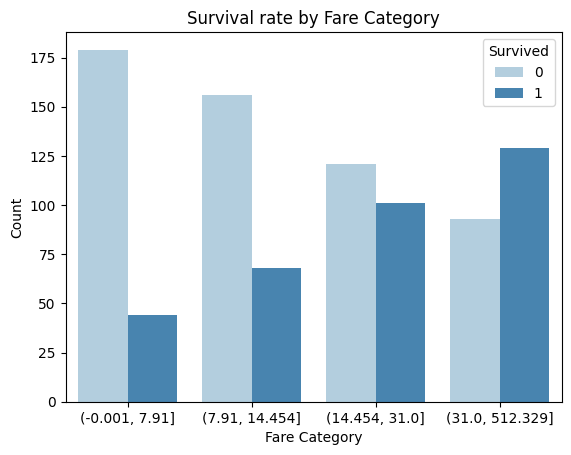

In [ ]:
sns.countplot(x='Fare_Category', hue='Survived', data=train_df, palette='Blues')
plt.title('Survival rate by Fare Category')
plt.xlabel('Fare Category')
plt.ylabel('Count')
plt.show()

- Distribution of fare:
  - A large number of passengers paid a lower fare while there are fewer passengers who paid increasingly higher fares. This indicates the fare distribution is skewed.
  - The distribution is skewed to the left side with 75% of the fare paid under `31$` with the max paid of `512$`.
- Relationship with Survival:
  - It became clear that passengers who paid higher fares had more chance of surviving. This suggests a strong positive correlation between the fare paid and the chance of survival.

### **4.3. Handling missing values**

In [ ]:
train_df.dropna(subset=['Age'], inplace=True)
test_df.dropna(subset=['Age'], inplace=True)

mode_embarked = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(mode_embarked)
test_df['Embarked'] = test_df['Embarked'].fillna(mode_embarked)

train_df['Cabin'] = train_df['Cabin'].fillna('Missing')
test_df['Cabin'] = test_df['Cabin'].fillna('Missing')

print("Missing values in Age after handling (Train):", train_df['Age'].isnull().sum())
print("Missing values in Age after handling (Test):", test_df['Age'].isnull().sum())
print("Missing values in Embarked after handling (Train):", train_df['Embarked'].isnull().sum())
print("Missing values in Embarked after handling (Test):", test_df['Embarked'].isnull().sum())
print("Missing values in Cabin after handling (Train):", train_df['Cabin'].isnull().sum())
print("Missing values in Cabin after handling (Test):", test_df['Cabin'].isnull().sum())

Missing values in Age after handling (Train): 0
Missing values in Age after handling (Test): 0
Missing values in Embarked after handling (Train): 0
Missing values in Embarked after handling (Test): 0
Missing values in Cabin after handling (Train): 0
Missing values in Cabin after handling (Test): 0


- **Embarked:** only had 2 missing values. In such case, it's preferable to fill the missing values with reasonable estimate information.
- **Age:** had a significantly large number of missing values (177 in the original training data). Dropping rows will keep the process simple.
- **Cabin:** this column had a very large number of missing values up to 687 (about 77.10%), we would removed a significant portion of the dataset if dropped, which is not ideal for analysis. Instead filling will allow us to keep all the rows and potentially explore.

### **Long**
**Mục tiêu:**
- Chuẩn bị dữ liệu & xử lý đặc trưng
- Huấn luyện mô hình baseline: 
    + Linear Algorithms: Logistic Regression 
    + Nonlinear Algorithms: Classi cation and Regression Trees (CART)

In [83]:
# Thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import joblib

# hiển thị đồ thị inline
%matplotlib inline
print("Ready")

Ready


In [68]:
# Load dữ liệu (place train.csv vào cùng thư mục notebook)
import os
print("Working dir:", os.getcwd())

try:
    train = pd.read_csv("train.csv")
    display(train.head())
    print("\nMissing summary:")
    print(train.isnull().sum())
except FileNotFoundError:
    print("Không tìm thấy file train.csv. Vui lòng đặt file train.csv vào thư mục làm việc và chạy lại notebook.")

Working dir: e:\KHDL\Khai phá dữ liệu\challenge_1_v2\sgu25-khaiphadulieu\challenge_1_titanic


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Missing summary:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### 1. Khảo sát nhanh (EDA)
Quan sát các biến, phân phối và mối quan hệ với `Survived`.

Shape: (891, 12)

Các giá trị duy nhất mỗi cột:
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


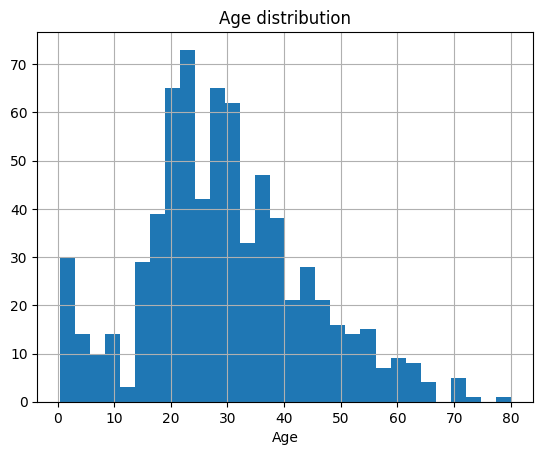

In [69]:
# Nếu train đã được load, thực hiện EDA cơ bản
if 'train' in globals():
    print('Shape:', train.shape)
    print('\nCác giá trị duy nhất mỗi cột:')
    print(train.nunique())
    # Tỷ lệ sống sót theo giới tính và hạng
    display(pd.crosstab(train['Sex'], train['Survived'], normalize='index'))
    display(pd.crosstab(train['Pclass'], train['Survived'], normalize='index'))
    # Biểu đồ tuổi
    train['Age'].hist(bins=30)
    plt.title('Age distribution')
    plt.xlabel('Age')
    plt.show()

### 2. Xử lý đặc trưng (Feature Engineering)
- Điền missing
- Tạo biến mới: `FamilySize`, `IsAlone`, `Title` (tách từ `Name`)
- Loại bỏ các cột ít hữu ích trực tiếp như `Ticket`, `Cabin` (có thể dùng sau này)

In [76]:
if 'train' in globals():
    df = train.copy()
    # Tạo FamilySize và IsAlone
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Extract Title từ Name
    df['Title'] = df['Name'].str.extract(',\s*([^\.]+)\.', expand=False)
    # Gom nhóm các title ít gặp
    df['Title'] = df['Title'].replace(['Mlle','Ms'],'Miss')
    df['Title'] = df['Title'].replace('Mme','Mrs')
    rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
    df['Title'] = df['Title'].replace(list(rare_titles), 'Rare')

    display(df[['Name','Title']].head())
    display(df[['FamilySize','IsAlone']].head())

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Dell 7480\AppData\Local\Temp\ipykernel_19008\713177670.py:8: SyntaxWarning: invalid escape sequence '\s'
  df['Title'] = df['Name'].str.extract(',\s*([^\.]+)\.', expand=False)


,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


### 3. Chọn features cho baseline
Chúng ta dùng các feature đơn giản: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`, `FamilySize`, `IsAlone`, `Title`.

In [77]:
if 'train' in globals():
    features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','FamilySize','IsAlone','Title']
    X = df[features].copy()
    y = df['Survived'].copy()
    X.head()

### 4. Pipeline tiền xử lý
- Impute numerical bằng median
- Impute categorical bằng mode
- One-hot encode categorical
- Standardize numeric trước khi đưa vào Logistic Regression

In [78]:
from sklearn.pipeline import make_pipeline

if 'train' in globals():
    numeric_features = ['Age','SibSp','Parch','Fare','FamilySize']
    categorical_features = ['Pclass','Sex','Embarked','IsAlone','Title']

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

In [79]:
if 'train' in globals():
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    # Build pipeline with logistic regression
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', LogisticRegression(max_iter=1000))])
    clf.fit(X_train, y_train)
    print("Done training baseline Logistic Regression")

Done training baseline Logistic Regression


Accuracy: 0.8547486033519553

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179


Confusion matrix:
 [[100  10]
 [ 16  53]]

ROC AUC: 0.8790513833992095


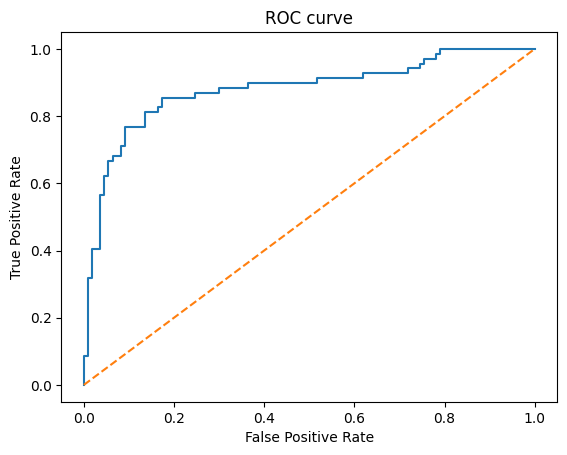

In [80]:
if 'train' in globals():
    y_pred = clf.predict(X_val)
    y_proba = clf.predict_proba(X_val)[:,1]
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("\nClassification report:\n", classification_report(y_val, y_pred))
    print("\nConfusion matrix:\n", confusion_matrix(y_val, y_pred))
    print("\nROC AUC:", roc_auc_score(y_val, y_proba))

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.show()

### 5. Cross-validation (tùy chọn)
Để kiểm tra ổn định, ta có thể chạy cross-val trên pipeline.

In [81]:
if 'train' in globals():
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    print("CV accuracy scores:", scores)
    print("Mean CV accuracy:", scores.mean())

CV accuracy scores: [0.82122905 0.81460674 0.80337079 0.80337079 0.87078652]
Mean CV accuracy: 0.8226727763480008


### 6. Lưu model
Lưu pipeline đã huấn luyện để dùng lại.

In [82]:
if 'train' in globals():
    joblib.dump(clf, 'titanic_logreg_baseline.joblib')
    print("Saved model to titanic_logreg_baseline.joblib")

Saved model to titanic_logreg_baseline.joblib


### 7. Classification and Regression Trees (CART)

In [ ]:
# Xác định biến
numeric_features = ['Age','SibSp','Parch','Fare','FamilySize']
categorical_features = ['Pclass','Sex','Embarked','IsAlone','Title']

numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [103]:
# CART model
cart_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [105]:
# Build pipeline
cart_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', cart_model)
])

# Train
cart_pipeline.fit(X_train, y_train)

# Predict
y_pred = cart_pipeline.predict(X_val)